# Bincom Election ML Submission

**Project Name:** Delta State Election Intelligence Segmentation  
**Project Type:** Exploratory Data Analysis and Unsupervised Machine Learning  
**Contribution:** Individual  
**Primary Objective:** Cluster Delta State LGAs that have announced polling-unit results and turn the clusters into decision-support strategy briefs.


## Project Summary

This submission investigates the 2011 Delta State election sample supplied in the Bincom assessment dataset. The underlying business question is not just who scored the most votes in absolute terms, but how different Local Government Areas (LGAs) behave when we compare turnout scale, party dominance, competitiveness, and result coverage. That matters because an election operations team, public policy unit, or local government analyst can use segmentation to decide where to defend strongholds, where to invest persuasion efforts, and where to improve polling-unit reporting quality.

The dataset contains all 25 Delta State LGAs, 263 wards, 272 polling-unit rows, and announced polling-unit results for only a subset of polling units. A key modeling constraint is that only **8 LGAs** have real announced polling-unit result rows. Because clustering needs actual numeric behavior rather than missing-result placeholders, the clustering model is built only on those 8 result-backed LGAs. The full set of 25 LGAs is still analyzed descriptively so that missing-result coverage and data completeness are not hidden.

The workflow in this notebook follows a practical machine learning process. First, the raw SQLite data is loaded from the project database rather than from a manually copied CSV. Next, the notebook checks data quality and quantifies how many LGAs have usable announced polling-unit results. Then it performs exploratory analysis on the full Delta State population and on the result-backed subset. Feature engineering converts party-level vote totals into LGA-level behavioral signals such as party vote shares, dominant-party share, competitiveness margin, vote dispersion, and coverage percentage. These features are scaled and compared with both StandardScaler and MinMaxScaler because clustering depends on feature distances.

For the model itself, this submission treats clustering as the correct “prediction” task. Instead of predicting a target label that the dataset does not provide, the notebook groups LGAs with similar election behavior using hierarchical agglomerative clustering as the preferred method, while K-means is used as a supporting benchmark. The model is evaluated with internal clustering metrics: silhouette score, Calinski-Harabasz score, Davies-Bouldin score, plus elbow and dendrogram diagnostics. The final section translates cluster outputs into practical strategy briefs so the analysis ends with an actionable conclusion rather than only charts and tables.


## Problem Statement

Bincom provided election results stored at polling-unit level, alongside LGA, ward, and polling-unit reference tables. The practical challenge is to understand:

1. how polling units are distributed across Delta State LGAs;
2. which LGAs actually have usable announced polling-unit results;
3. how party behavior differs across result-backed LGAs; and
4. whether LGAs can be segmented into meaningful groups for strategy and decision support.

Because the source does not provide a clean supervised learning target, this notebook frames the machine learning problem as **unsupervised clustering** of result-backed LGAs.


## Reproducibility

Run the following from the repository root before executing the notebook:

```bash
pip install -r requirements-analytics.txt
python manage.py migrate
python manage.py import_bincom_sql
python scripts/build_lga_modeling_dataset.py
```

The notebook reads from `db.sqlite3`, regenerates CSV artifacts in `analysis_outputs/`, and can be executed top-to-bottom without manual editing.


## 1. Project Setup and Library Imports


In [3]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if not os.environ.get("LOKY_MAX_CPU_COUNT"):
    os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore")

from scripts.election_ml_pipeline import (
    PARTY_ORDER,
    build_cluster_profiles,
    build_completeness_table,
    build_dendrogram_linkage,
    build_lga_result_long,
    build_lga_summary,
    build_modeling_dataset,
    build_party_share_table,
    choose_final_clustering,
    evaluate_clustering_options,
    export_ml_artifacts,
    fit_final_clustering,
    get_feature_columns,
    load_election_frames,
    scale_features,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


In [4]:
output_paths = export_ml_artifacts(db_path="db.sqlite3", out_dir="analysis_outputs")
frames = load_election_frames("db.sqlite3")
completeness_df = build_completeness_table(frames)
result_long_df = build_lga_result_long(frames)
lga_summary_df = build_lga_summary(frames)
party_share_df = build_party_share_table(frames)
modeling_df = build_modeling_dataset(frames)
feature_columns = get_feature_columns(modeling_df)
scaled_feature_sets = scale_features(modeling_df, feature_columns)
evaluation_df = evaluate_clustering_options(modeling_df, feature_columns)
clustered_df, evaluation_df = fit_final_clustering(modeling_df, feature_columns)
cluster_profiles_df = build_cluster_profiles(clustered_df, feature_columns)
final_method, final_k = choose_final_clustering(evaluation_df)

print("Artifacts written:")
for name, path in output_paths.items():
    print(f"- {name}: {path}")
print(f"Final clustering choice: {final_method} with k={final_k}")


Artifacts written:
- polling_unit_completeness: analysis_outputs/polling_unit_completeness.csv
- lga_summary: analysis_outputs/lga_summary.csv
- party_share: analysis_outputs/party_share.csv
- lga_modeling_dataset: analysis_outputs/lga_modeling_dataset.csv
Final clustering choice: hierarchical_ward with k=3


## 2. Understanding the Election Dataset and Why Only 8 LGAs Are Cluster-Eligible


In [5]:
dataset_overview = pd.DataFrame(
    [
        {"metric": "Delta State LGAs", "value": completeness_df.shape[0]},
        {"metric": "Wards", "value": frames["ward"].shape[0]},
        {"metric": "Polling unit rows", "value": frames["polling_unit"].shape[0]},
        {"metric": "Usable polling units", "value": int(completeness_df["polling_units_with_metadata"].sum())},
        {"metric": "Result-backed LGAs", "value": modeling_df.shape[0]},
        {"metric": "Announced polling-unit result rows", "value": frames["announced_pu_results"].shape[0]},
    ]
)
display(dataset_overview)

display(
    modeling_df[
        ["lga_id", "lga_name", "polling_units_with_results", "coverage_pct", "total_votes", "dominant_party"]
    ].sort_values("total_votes", ascending=False)
)


,metric,value
0,Delta State LGAs,25
1,Wards,263
2,Polling unit rows,272
3,Usable polling units,102
4,Result-backed LGAs,8
5,Announced polling-unit result rows,150


,lga_id,lga_name,polling_units_with_results,coverage_pct,total_votes,dominant_party
5,6,Ethiope West,4,28.5700,"24,692.0000",PDP
21,22,Uvwie,5,50.0000,"20,420.0000",ANPP
24,35,Warri South West,3,27.2700,"15,824.0000",PDP
18,19,Ughelli North,2,50.0000,"12,280.0000",DPP
7,7,Ika North - East,1,100.0000,"4,780.0000",PDP
20,21,Ukwuani,1,25.0000,"3,722.0000",PPA
23,34,Warri South,1,16.6700,"3,718.0000",ACN
16,17,Sapele,1,50.0000,"3,369.0000",PPA


The full Delta State reference data contains **25 LGAs**, but only **8 LGAs** have announced polling-unit result rows that can support clustering. That is why the notebook treats the 25-LGA population as a descriptive analysis problem, while the clustering model is restricted to the 8 result-backed LGAs.


## 3. Data Loading and Schema Overview


In [6]:
schema_overview = pd.DataFrame(
    [
        {"table": name, "rows": frame.shape[0], "columns": ", ".join(frame.columns[:8])}
        for name, frame in frames.items()
    ]
)
display(schema_overview)
display(frames["lga"].head())
display(frames["polling_unit"].head())
display(frames["announced_pu_results"].head())


,table,rows,columns
0,lga,25,"uniqueid, lga_id, lga_name, state_id"
1,ward,263,"uniqueid, ward_id, ward_name, lga_id"
2,polling_unit,272,"uniqueid, polling_unit_id, ward_id, lga_id, un..."
3,announced_pu_results,150,"result_id, polling_unit_uniqueid, party_abbrev..."
4,announced_lga_results,225,"result_id, lga_name, party_abbreviation, party..."


,uniqueid,lga_id,lga_name,state_id
0,2,2,Aniocha - South,25
1,1,1,Aniocha North,25
2,21,31,Bomadi,25
3,22,32,Burutu,25
4,3,5,Ethiope East,25


,uniqueid,polling_unit_id,ward_id,lga_id,uniquewardid,polling_unit_number,polling_unit_name,polling_unit_description
0,8,6,8,17,181,DT1708006,Sapele Ward 8 PU _,NaN
1,9,4,1,19,194,DT1901004,Primary School in Aghara,Primary School in Aghara
2,10,5,1,19,194,DT1401005,Ishere Primary School Aghara,Ishere Primary School Aghara
3,11,5,3,34,244,DT3403005,Igini Primary School,Esisi Road
4,12,1,4,21,220,DT2104001,Umukwapa poll unit 1,NaN


,result_id,polling_unit_uniqueid,party_abbreviation,party_score,entered_by_user,date_entered
0,111,8,PDP,802,Bose,2011-04-26 14:44:03
1,112,8,DPP,719,Bose,2011-04-26 14:44:03
2,113,8,ACN,416,Bose,2011-04-26 14:44:03
3,114,8,PPA,939,Bose,2011-04-26 14:44:03
4,115,8,CDC,394,Bose,2011-04-26 14:44:03


## 4. Data Quality Checks


In [8]:
missing_summary = pd.DataFrame(
    [
        {
            "table": name,
            "column": column,
            "missing_values": int(frame[column].isna().sum()),
        }
        for name, frame in frames.items()
        for column in frame.columns
    ]
)
display(missing_summary.loc[missing_summary["missing_values"] > 0].sort_values(["table", "missing_values"], ascending=[True, False]).head(20))

no_result_lgas = completeness_df.loc[
    completeness_df["polling_units_with_results"] == 0,
    ["lga_name", "polling_units_with_metadata", "result_status"],
].sort_values("polling_units_with_metadata", ascending=False)
display(no_result_lgas.head(10))


,table,column,missing_values
15,polling_unit,polling_unit_description,4


,lga_name,polling_units_with_metadata,result_status
14,Oshimili - South,19,no announced polling-unit results available
2,Bomadi,18,no announced polling-unit results available
1,Aniocha North,4,no announced polling-unit results available
10,Ndokwa East,2,no announced polling-unit results available
9,Isoko South,2,no announced polling-unit results available
8,Isoko North,2,no announced polling-unit results available
0,Aniocha - South,1,no announced polling-unit results available
12,Okpe,1,no announced polling-unit results available
3,Burutu,1,no announced polling-unit results available
6,Ika - South,0,no announced polling-unit results available


Missingness in this project is not only about blank cells. A more important issue is **missing election coverage**: many LGAs have usable polling-unit metadata but no announced polling-unit result rows. Those LGAs are retained for descriptive analysis but excluded from clustering so the model does not confuse “no result was recorded” with “zero votes were cast”.


## 5. EDA on All 25 LGAs


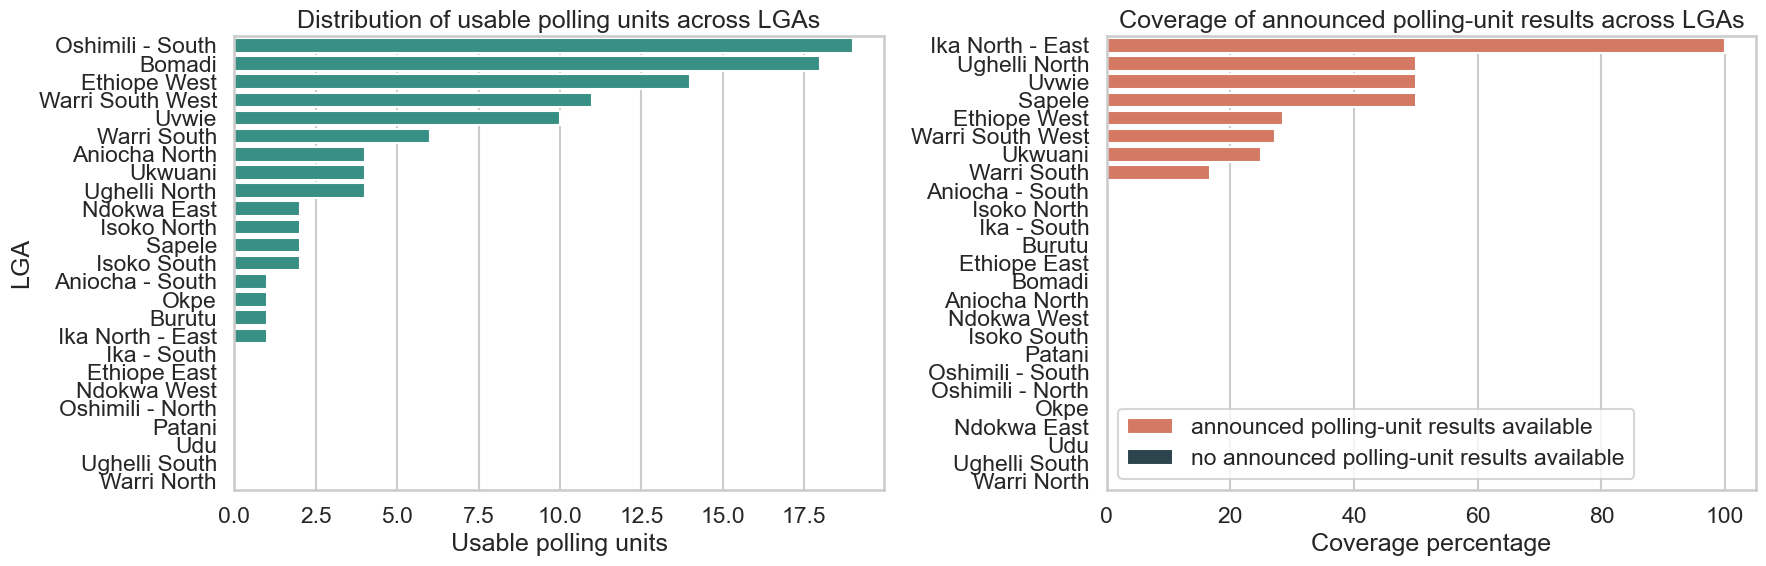

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

completeness_plot = completeness_df.sort_values("polling_units_with_metadata", ascending=False)
sns.barplot(
    data=completeness_plot,
    x="polling_units_with_metadata",
    y="lga_name",
    color="#2a9d8f",
    ax=axes[0],
)
axes[0].set_title("Distribution of usable polling units across LGAs")
axes[0].set_xlabel("Usable polling units")
axes[0].set_ylabel("LGA")

coverage_plot = completeness_df.sort_values("coverage_pct", ascending=False)
sns.barplot(
    data=coverage_plot,
    x="coverage_pct",
    y="lga_name",
    hue="result_status",
    dodge=False,
    palette=["#e76f51", "#264653"],
    ax=axes[1],
)
axes[1].set_title("Coverage of announced polling-unit results across LGAs")
axes[1].set_xlabel("Coverage percentage")
axes[1].set_ylabel("")
axes[1].legend(title="")

plt.tight_layout()
plt.show()


Two patterns stand out. First, the number of usable polling units is uneven across LGAs, so the descriptive population is not balanced. Second, announced polling-unit coverage is sparse: most LGAs have zero announced result coverage, which means any machine learning model that depends on vote behavior must be built on the smaller result-backed subset instead of the full 25-LGA reference list.


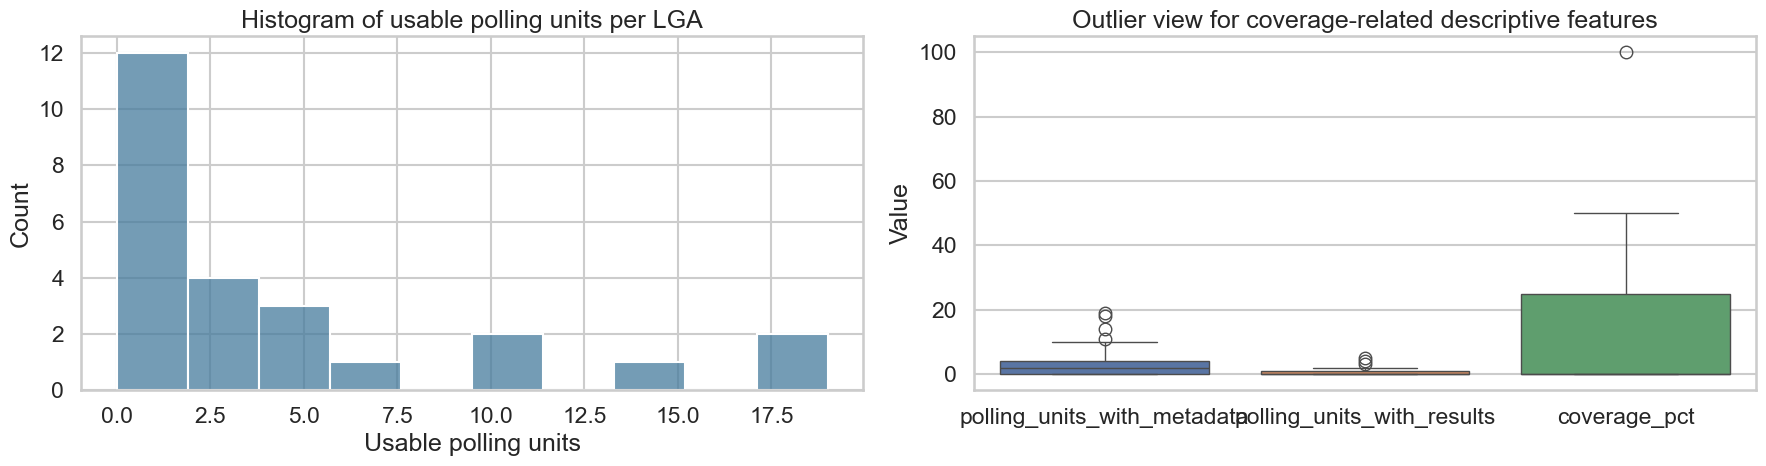

,lga_id,lga_name,polling_units_with_metadata,polling_units_with_results,coverage_pct,result_status
14,15,Oshimili - South,19,0,0.0000,no announced polling-unit results available
2,31,Bomadi,18,0,0.0000,no announced polling-unit results available
5,6,Ethiope West,14,4,28.5714,announced polling-unit results available
24,35,Warri South West,11,3,27.2727,announced polling-unit results available
21,22,Uvwie,10,5,50.0000,announced polling-unit results available
23,34,Warri South,6,1,16.6667,announced polling-unit results available
1,1,Aniocha North,4,0,0.0000,no announced polling-unit results available
20,21,Ukwuani,4,1,25.0000,announced polling-unit results available
18,19,Ughelli North,4,2,50.0000,announced polling-unit results available
10,11,Ndokwa East,2,0,0.0000,no announced polling-unit results available


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(completeness_df["polling_units_with_metadata"], bins=10, kde=False, color="#457b9d", ax=axes[0])
axes[0].set_title("Histogram of usable polling units per LGA")
axes[0].set_xlabel("Usable polling units")

sns.boxplot(data=completeness_df[["polling_units_with_metadata", "polling_units_with_results", "coverage_pct"]], ax=axes[1])
axes[1].set_title("Outlier view for coverage-related descriptive features")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

completeness_df.sort_values("polling_units_with_metadata", ascending=False).head(10)


The coverage-related features have visible dispersion and some LGA-level extremes. At this stage the notebook only **observes** outliers; it does not delete them. That matches the project rule that unusual LGAs should be discussed before any transformation is considered.


## 6. EDA on Result-Backed LGAs


In [11]:
result_backed_summary = modeling_df[
    [
        "lga_name",
        "polling_units_with_results",
        "coverage_pct",
        "total_votes",
        "dominant_party",
        "dominant_party_share",
        "competitiveness_margin",
    ]
].sort_values("total_votes", ascending=False)
display(result_backed_summary)


,lga_name,polling_units_with_results,coverage_pct,total_votes,dominant_party,dominant_party_share,competitiveness_margin
5,Ethiope West,4,28.5700,"24,692.0000",PDP,0.2088,0.0693
21,Uvwie,5,50.0000,"20,420.0000",ANPP,0.1531,0.0039
24,Warri South West,3,27.2700,"15,824.0000",PDP,0.1709,0.0269
18,Ughelli North,2,50.0000,"12,280.0000",DPP,0.2476,0.0932
7,Ika North - East,1,100.0000,"4,780.0000",PDP,0.2464,0.0412
20,Ukwuani,1,25.0000,"3,722.0000",PPA,0.2810,0.0019
23,Warri South,1,16.6700,"3,718.0000",ACN,0.2464,0.0750
16,Sapele,1,50.0000,"3,369.0000",PPA,0.2787,0.0407


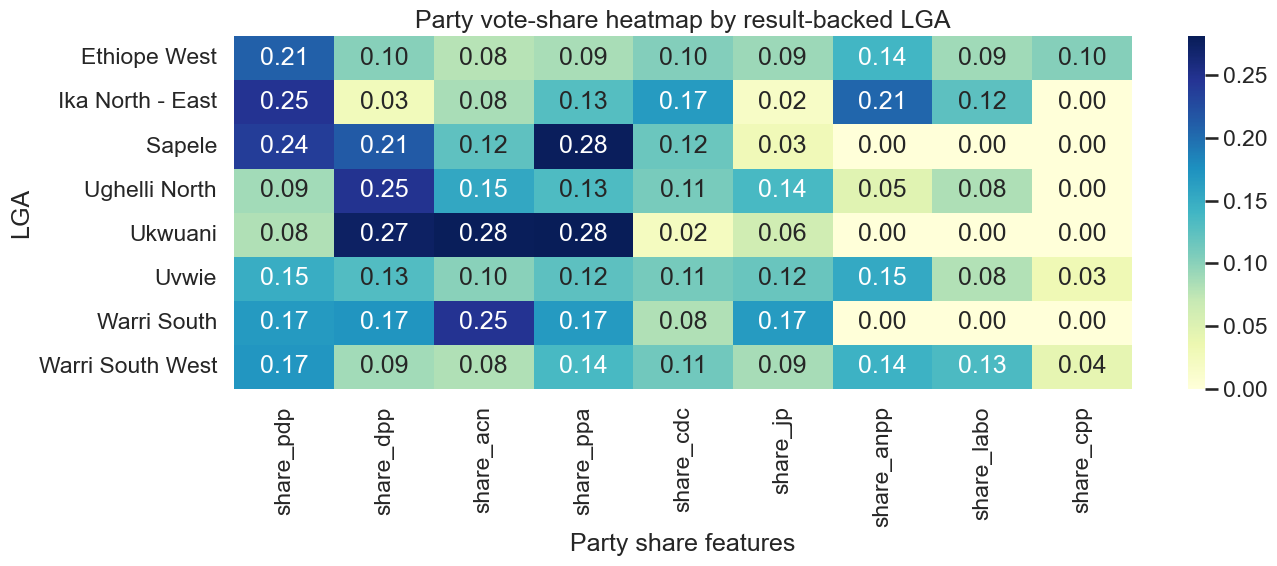

In [12]:
party_share_heatmap = modeling_df.set_index("lga_name")[[f"share_{party.lower()}" for party in PARTY_ORDER]]
plt.figure(figsize=(14, 6))
sns.heatmap(party_share_heatmap, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Party vote-share heatmap by result-backed LGA")
plt.xlabel("Party share features")
plt.ylabel("LGA")
plt.tight_layout()
plt.show()


The party-share heatmap shows that the result-backed LGAs are not interchangeable. Some LGAs are dominated by one party, while others have flatter share profiles. This is exactly the type of structure clustering is meant to capture.


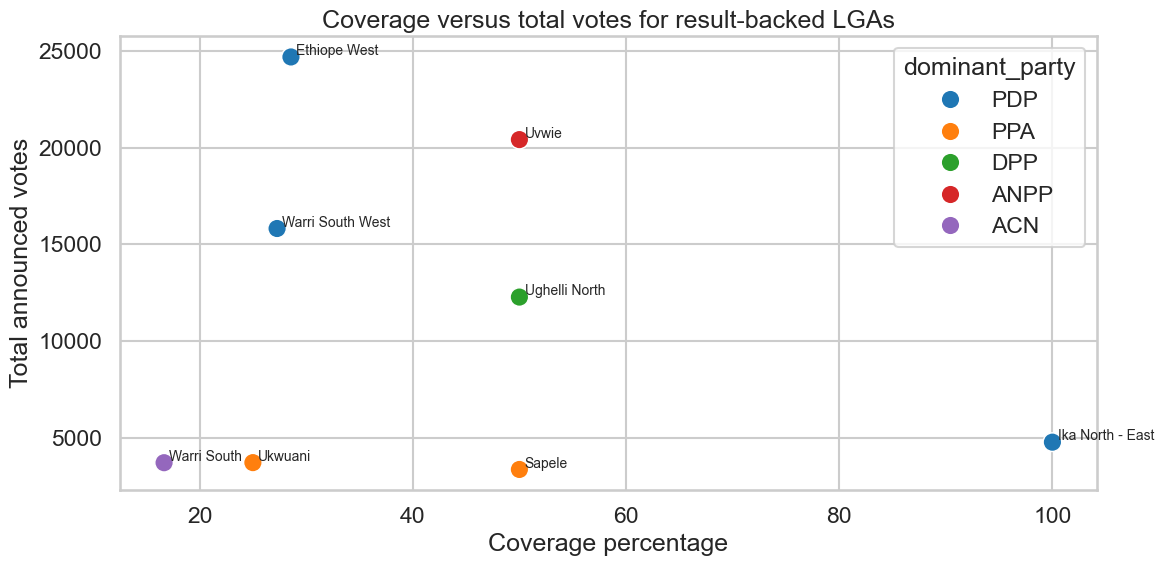

In [13]:
plt.figure(figsize=(12, 6))
ax = sns.scatterplot(
    data=modeling_df,
    x="coverage_pct",
    y="total_votes",
    hue="dominant_party",
    s=180,
    palette="tab10",
)
for _, row in modeling_df.iterrows():
    ax.text(row["coverage_pct"] + 0.5, row["total_votes"] + 100, row["lga_name"], fontsize=10)
plt.title("Coverage versus total votes for result-backed LGAs")
plt.xlabel("Coverage percentage")
plt.ylabel("Total announced votes")
plt.tight_layout()
plt.show()


Coverage and total votes do not move perfectly together. Uvwie and Ethiope West are high-volume LGAs, while Ika North - East has perfect coverage within a much smaller result base. That supports the idea that scale and reporting coverage should both be included as features.


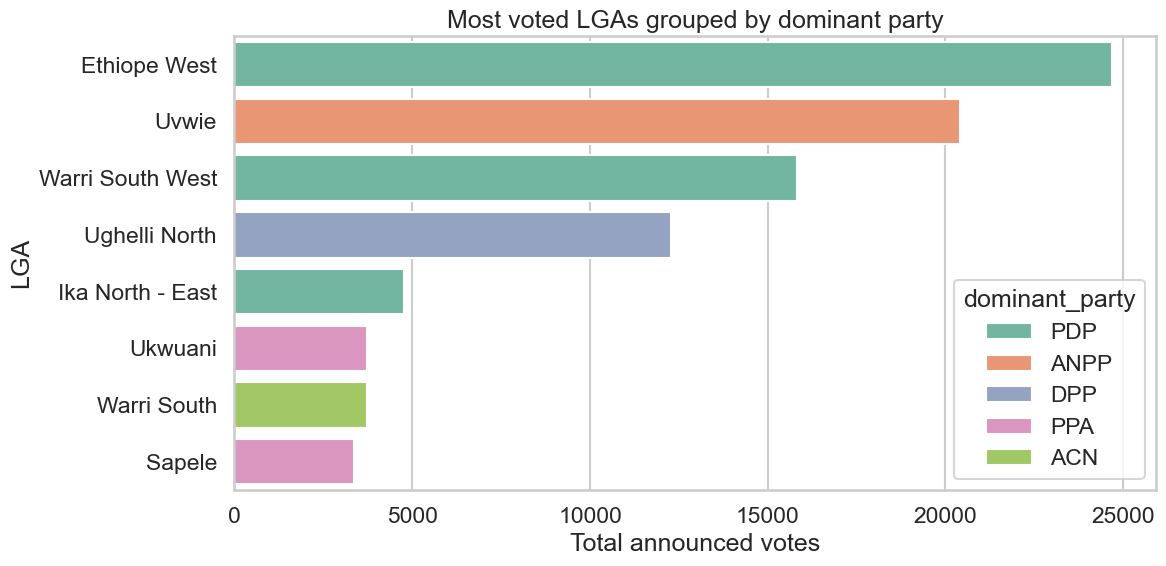

,lga_name,total_votes,dominant_party
5,Ethiope West,"24,692.0000",PDP
21,Uvwie,"20,420.0000",ANPP
24,Warri South West,"15,824.0000",PDP
18,Ughelli North,"12,280.0000",DPP
7,Ika North - East,"4,780.0000",PDP
20,Ukwuani,"3,722.0000",PPA
23,Warri South,"3,718.0000",ACN
16,Sapele,"3,369.0000",PPA


In [14]:
most_voted_lga = modeling_df.sort_values("total_votes", ascending=False)[["lga_name", "total_votes", "dominant_party"]]

plt.figure(figsize=(12, 6))
sns.barplot(data=most_voted_lga, x="total_votes", y="lga_name", hue="dominant_party", dodge=False, palette="Set2")
plt.title("Most voted LGAs grouped by dominant party")
plt.xlabel("Total announced votes")
plt.ylabel("LGA")
plt.tight_layout()
plt.show()

display(most_voted_lga)


The most-voted LGAs are not all dominated by the same party. That matters for strategy because high-volume LGAs can be large opportunities or large risks depending on whether competition is narrow or one-sided.


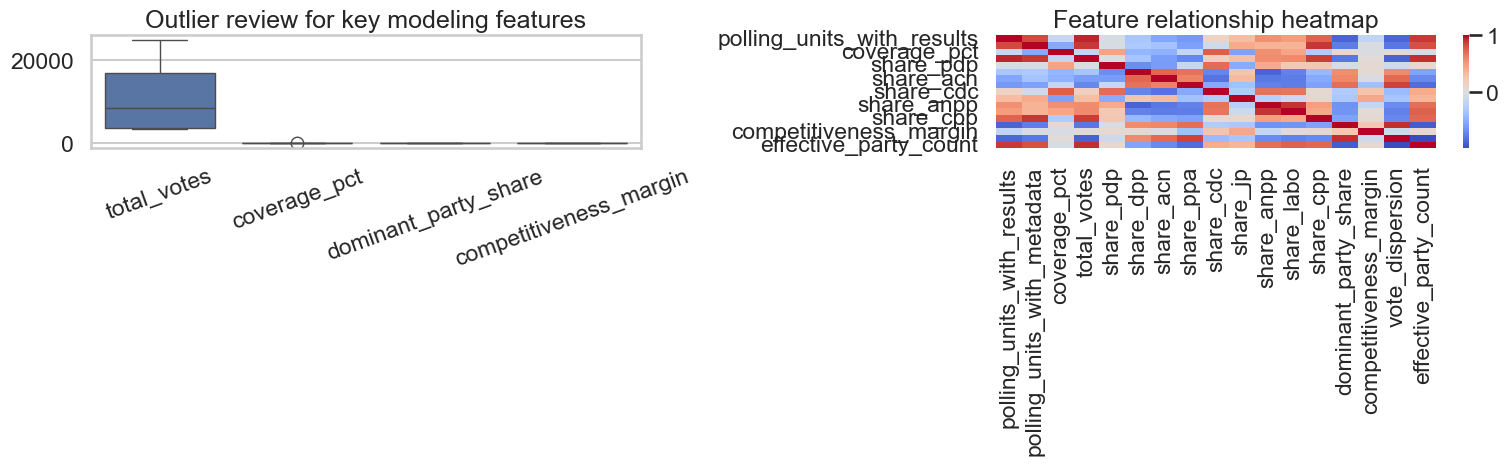

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=modeling_df[["total_votes", "coverage_pct", "dominant_party_share", "competitiveness_margin"]], ax=axes[0])
axes[0].set_title("Outlier review for key modeling features")
axes[0].tick_params(axis="x", rotation=20)

sns.heatmap(modeling_df[feature_columns].corr(), cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Feature relationship heatmap")

plt.tight_layout()
plt.show()


The outlier review shows real variation in total votes and coverage, but no feature is removed automatically. The relationship heatmap also shows that some engineered variables overlap conceptually, which is expected because dominant-party share and competitiveness margin both describe concentration of support.


## 7. Feature Engineering


In [17]:
feature_definitions = pd.DataFrame(
    [
        {"feature": "polling_units_with_results", "meaning": "How many usable polling units in the LGA have announced party scores."},
        {"feature": "polling_units_with_metadata", "meaning": "How many usable polling units are listed for the LGA in the reference table."},
        {"feature": "coverage_pct", "meaning": "Percentage of usable polling units that have announced results."},
        {"feature": "total_votes", "meaning": "Sum of announced votes across all parties for the LGA."},
        {"feature": "share_<party>", "meaning": "Vote share contributed by each party in the LGA."},
        {"feature": "dominant_party_share", "meaning": "Largest party share in the LGA."},
        {"feature": "competitiveness_margin", "meaning": "Difference between the top party share and the second party share."},
        {"feature": "vote_dispersion", "meaning": "Spread of party shares within the LGA."},
        {"feature": "effective_party_count", "meaning": "Compact measure of how fragmented the vote is across parties."},
    ]
)
display(feature_definitions)
display(modeling_df[["lga_name", *feature_columns]].head())


,feature,meaning
0,polling_units_with_results,How many usable polling units in the LGA have ...
1,polling_units_with_metadata,How many usable polling units are listed for t...
2,coverage_pct,Percentage of usable polling units that have a...
3,total_votes,Sum of announced votes across all parties for ...
4,share_<party>,Vote share contributed by each party in the LGA.
5,dominant_party_share,Largest party share in the LGA.
6,competitiveness_margin,Difference between the top party share and the...
7,vote_dispersion,Spread of party shares within the LGA.
8,effective_party_count,Compact measure of how fragmented the vote is ...


,lga_name,polling_units_with_results,polling_units_with_metadata,coverage_pct,total_votes,share_pdp,share_dpp,share_acn,share_ppa,share_cdc,share_jp,share_anpp,share_labo,share_cpp,dominant_party_share,competitiveness_margin,vote_dispersion,effective_party_count
5,Ethiope West,4,14,28.5700,"24,692.0000",0.2088,0.1010,0.0780,0.0852,0.1035,0.0916,0.1395,0.0896,0.1028,0.2088,0.0693,0.0406,8.0455
7,Ika North - East,1,1,100.0000,"4,780.0000",0.2464,0.0270,0.0849,0.1285,0.1661,0.0172,0.2052,0.1247,0.0000,0.2464,0.0412,0.0863,5.8572
16,Sapele,1,2,50.0000,"3,369.0000",0.2381,0.2134,0.1235,0.2787,0.1169,0.0294,0.0000,0.0000,0.0000,0.2787,0.0407,0.1110,4.7690
18,Ughelli North,2,4,50.0000,"12,280.0000",0.0881,0.2476,0.1545,0.1332,0.1098,0.1369,0.0475,0.0824,0.0000,0.2476,0.0932,0.0702,6.6430
20,Ukwuani,1,4,25.0000,"3,722.0000",0.0822,0.2738,0.2792,0.2810,0.0223,0.0615,0.0000,0.0000,0.0000,0.2810,0.0019,0.1283,4.1169


These engineered features convert raw party totals into behavior-oriented signals. The vote-share features describe party composition, while coverage, competitiveness, and dispersion describe the quality and structure of the electoral environment.


## 8. Preprocessing and Scaling Comparison


In [18]:
standard_scaled = scaled_feature_sets["standard"]
minmax_scaled = scaled_feature_sets["minmax"]

scaling_comparison = pd.DataFrame(
    {
        "feature": feature_columns,
        "raw_mean": modeling_df[feature_columns].mean().values,
        "raw_std": modeling_df[feature_columns].std().values,
        "standard_mean": standard_scaled.mean().values,
        "standard_std": standard_scaled.std().values,
        "minmax_min": minmax_scaled.min().values,
        "minmax_max": minmax_scaled.max().values,
    }
)
display(scaling_comparison.round(4))


,feature,raw_mean,raw_std,standard_mean,standard_std,minmax_min,minmax_max
0,polling_units_with_results,2.2500,1.5811,0.0000,1.0690,0.0000,1.0000
1,polling_units_with_metadata,6.5000,4.6599,0.0000,1.0690,0.0000,1.0000
2,coverage_pct,43.4388,26.3693,0.0000,1.0690,0.0000,1.0000
3,total_votes,"11,100.6250","8,484.8858",-0.0000,1.0690,0.0000,1.0000
4,share_pdp,0.1688,0.0619,0.0000,1.0690,0.0000,1.0000
5,share_dpp,0.1566,0.0851,-0.0000,1.0690,0.0000,1.0000
6,share_acn,0.1437,0.0782,-0.0000,1.0690,0.0000,1.0000
7,share_ppa,0.1669,0.0732,-0.0000,1.0690,0.0000,1.0000
8,share_cdc,0.1032,0.0403,-0.0000,1.0690,0.0000,1.0000
9,share_jp,0.0884,0.0515,0.0000,1.0690,0.0000,1.0000


StandardScaler is chosen for the final clustering workflow because the features have different numeric scales and clustering uses distance. Standard scaling centers each feature around zero and gives it comparable variance, while MinMaxScaler is kept as a sensitivity check rather than the default.


## 9. Clustering Model Selection


In [19]:
display(evaluation_df.round(4))


,method,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,inertia
0,hierarchical_ward,3,0.3103,4.8898,0.6799,NaN
1,hierarchical_ward,2,0.2955,4.8359,1.0700,NaN
2,hierarchical_ward,4,0.2676,5.1522,0.7480,NaN
3,kmeans,3,0.3103,4.8898,0.6799,46.0092
4,kmeans,2,0.2955,4.8359,1.0700,75.3049
5,kmeans,4,0.2676,5.1522,0.7480,27.9598


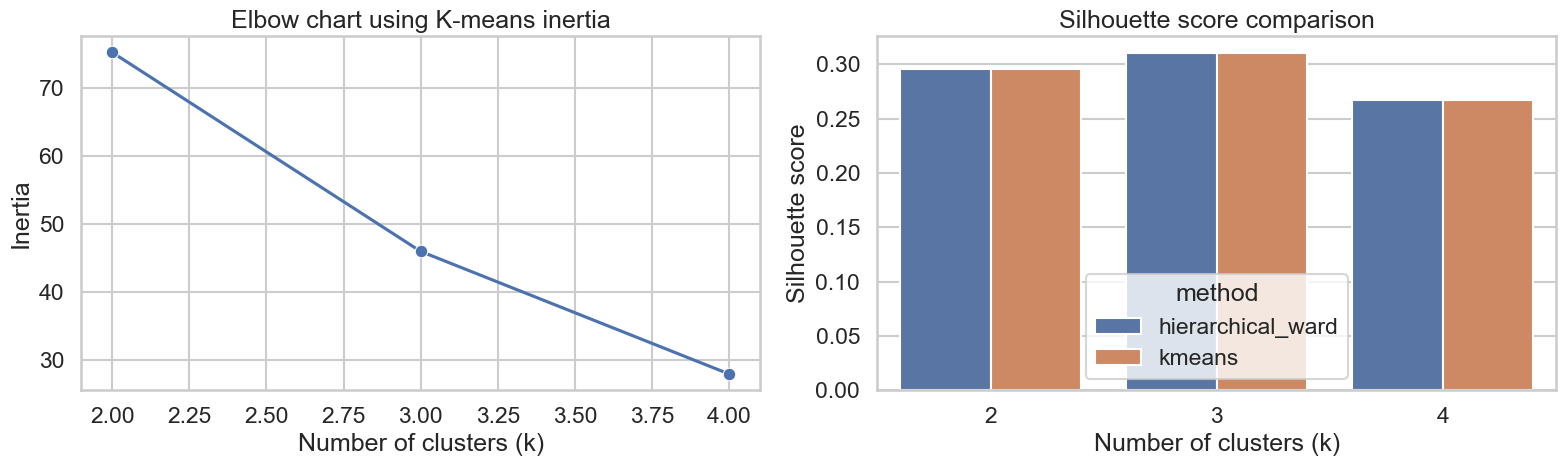

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

kmeans_rows = evaluation_df.loc[evaluation_df["method"] == "kmeans"].sort_values("k")
sns.lineplot(data=kmeans_rows, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("Elbow chart using K-means inertia")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

sns.barplot(data=evaluation_df, x="k", y="silhouette_score", hue="method", ax=axes[1])
axes[1].set_title("Silhouette score comparison")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()


The elbow chart provides a supporting K-means diagnostic, while the silhouette chart compares methods directly. In this dataset, both methods point toward the same practical region, and the final rule keeps hierarchical clustering as the default unless another method is clearly better and more interpretable.


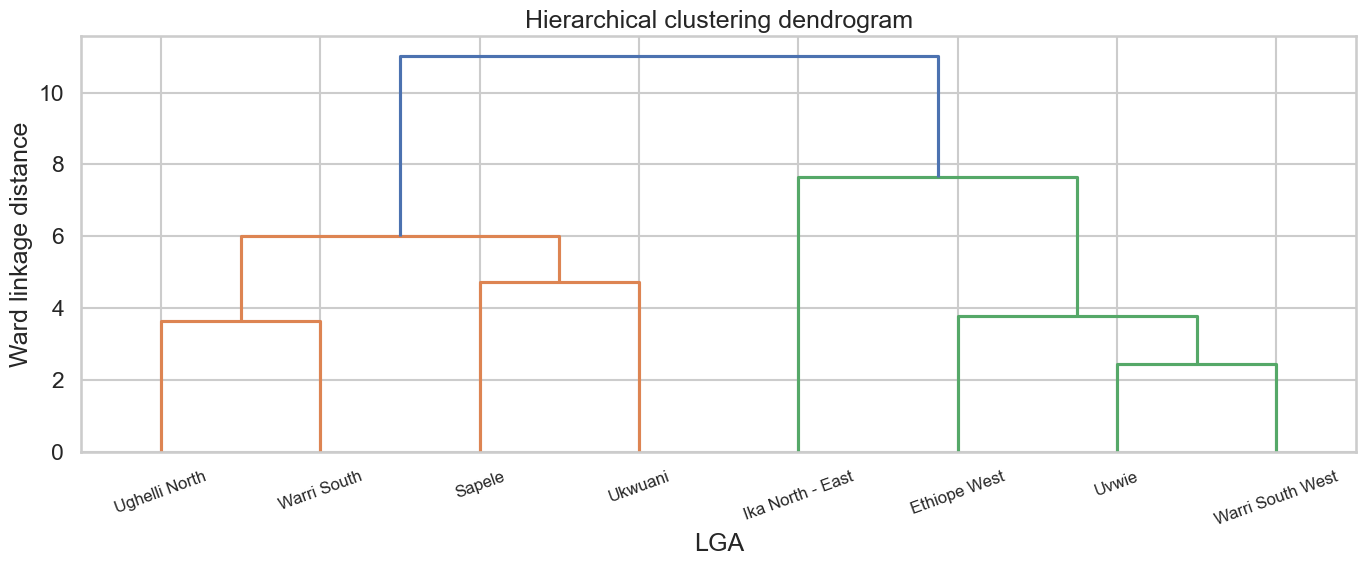

In [21]:
from scipy.cluster.hierarchy import dendrogram

linkage_matrix = build_dendrogram_linkage(modeling_df, feature_columns)
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, labels=modeling_df["lga_name"].tolist(), leaf_rotation=20)
plt.title("Hierarchical clustering dendrogram")
plt.xlabel("LGA")
plt.ylabel("Ward linkage distance")
plt.tight_layout()
plt.show()


The dendrogram supports a three-cluster interpretation: one broad competitive cluster, one high-volume cluster, and one small but distinct high-coverage cluster. That is consistent with the internal validation scores, so the final solution uses a **3-cluster hierarchical model**.


## 10. Cluster Visualization and Interpretation


In [22]:
display(
    clustered_df[
        [
            "lga_name",
            "cluster_id",
            "final_method",
            "final_k",
            "dominant_party",
            "total_votes",
            "coverage_pct",
            "competitiveness_margin",
        ]
    ].sort_values(["cluster_id", "total_votes"], ascending=[True, False])
)


,lga_name,cluster_id,final_method,final_k,dominant_party,total_votes,coverage_pct,competitiveness_margin
18,Ughelli North,0,hierarchical_ward,3,DPP,"12,280.0000",50.0000,0.0932
20,Ukwuani,0,hierarchical_ward,3,PPA,"3,722.0000",25.0000,0.0019
23,Warri South,0,hierarchical_ward,3,ACN,"3,718.0000",16.6700,0.0750
16,Sapele,0,hierarchical_ward,3,PPA,"3,369.0000",50.0000,0.0407
5,Ethiope West,1,hierarchical_ward,3,PDP,"24,692.0000",28.5700,0.0693
21,Uvwie,1,hierarchical_ward,3,ANPP,"20,420.0000",50.0000,0.0039
24,Warri South West,1,hierarchical_ward,3,PDP,"15,824.0000",27.2700,0.0269
7,Ika North - East,2,hierarchical_ward,3,PDP,"4,780.0000",100.0000,0.0412


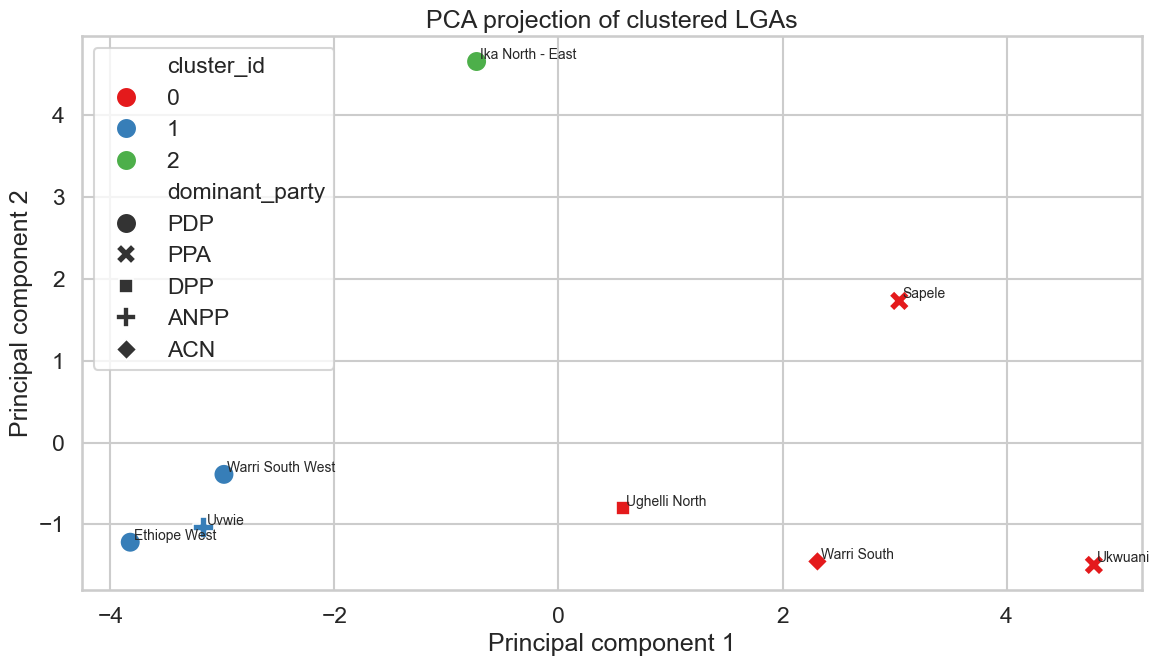

In [23]:
plt.figure(figsize=(12, 7))
ax = sns.scatterplot(
    data=clustered_df,
    x="pca_1",
    y="pca_2",
    hue="cluster_id",
    style="dominant_party",
    s=220,
    palette="Set1",
)
for _, row in clustered_df.iterrows():
    ax.text(row["pca_1"] + 0.03, row["pca_2"] + 0.03, row["lga_name"], fontsize=10)
plt.title("PCA projection of clustered LGAs")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.tight_layout()
plt.show()


The PCA view shows that the clusters are not random labels pasted onto the data. The LGAs separate in a way that matches differences in vote scale, coverage, and competitiveness. Because the sample size is only eight LGAs, the plot should be treated as decision support rather than a strong scientific proof.


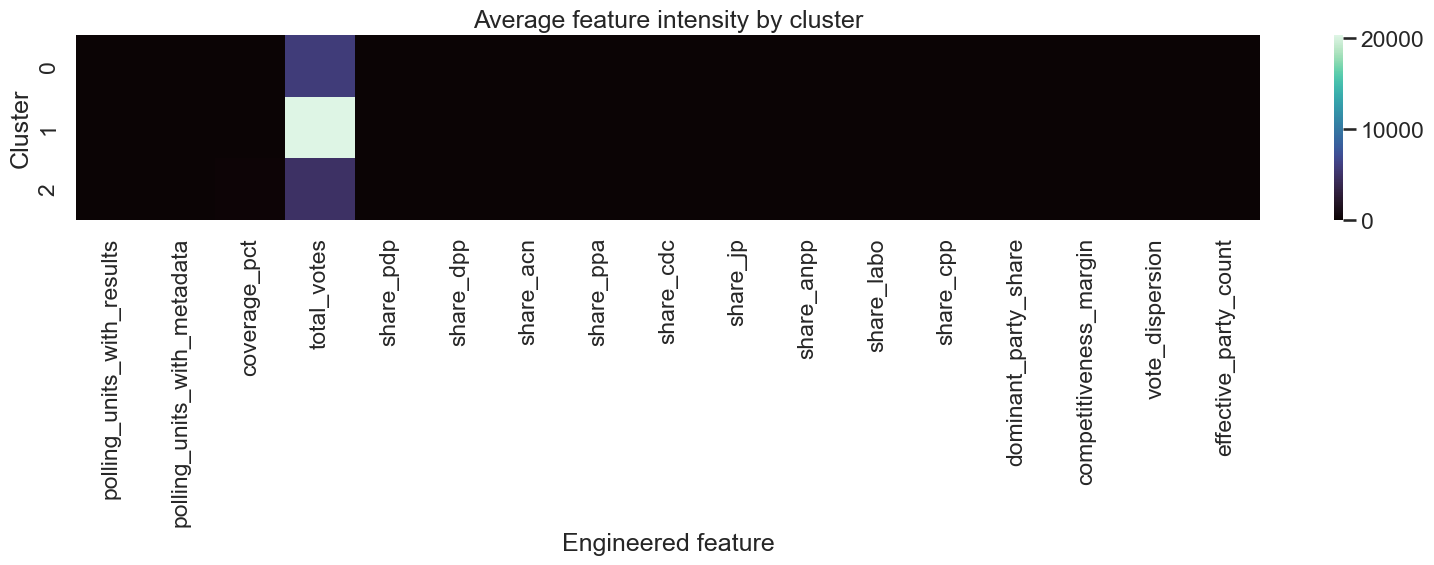

In [24]:
cluster_heatmap = clustered_df.groupby("cluster_id")[feature_columns].mean()
plt.figure(figsize=(16, 6))
sns.heatmap(cluster_heatmap, cmap="mako", annot=False)
plt.title("Average feature intensity by cluster")
plt.xlabel("Engineered feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


The cluster heatmap confirms that each segment is driven by a different mix of volume, coverage, and party concentration. This is the core reason the clustering output is useful: it reduces many party-level columns into a smaller number of operational segments.


## 11. Strategy Brief for Each Segment / Cluster


In [25]:
cluster_profiles_export = cluster_profiles_df.merge(
    clustered_df.groupby("cluster_id")["lga_name"].apply(lambda values: ", ".join(sorted(values))).rename("lga_members"),
    on="cluster_id",
    how="left",
)
display(cluster_profiles_export.round(4))


,cluster_id,total_votes,coverage_pct,dominant_party_share,competitiveness_margin,vote_dispersion,cluster_label,strategy_brief,lga_members
0,0,"5,772.2500",35.4175,0.2634,0.0527,0.1006,lower-volume focused LGAs,"Use targeted local messaging, ward-level mobil...","Sapele, Ughelli North, Ukwuani, Warri South"
1,1,"20,312.0000",35.2800,0.1776,0.0334,0.0392,high-volume competitive LGAs,"Prioritize coalition building, turnout protect...","Ethiope West, Uvwie, Warri South West"
2,2,"4,780.0000",100.0000,0.2464,0.0412,0.0863,lower-volume focused LGAs,"Use targeted local messaging, ward-level mobil...",Ika North - East


In [26]:
cluster_profiles_export.to_csv("analysis_outputs/cluster_profiles.csv", index=False)
clustered_df.to_csv("analysis_outputs/cluster_assignments.csv", index=False)
print("Saved analysis_outputs/cluster_profiles.csv")
print("Saved analysis_outputs/cluster_assignments.csv")


Saved analysis_outputs/cluster_profiles.csv
Saved analysis_outputs/cluster_assignments.csv


**Cluster 0:** lower-volume focused LGAs.  
These LGAs should receive targeted ward-level mobilization, low-cost field operations, and sharper local messaging because the total vote base is smaller and gains can come from disciplined execution.

**Cluster 1:** high-volume competitive LGAs.  
These LGAs deserve the strongest election-day operations, turnout protection, agent coverage, and rapid incident monitoring because they combine scale with meaningful competition.

**Cluster 2:** distinct high-coverage smaller LGAs.  
These LGAs are analytically valuable because coverage is high and behavior is clear. They can be used as signal-rich benchmarks for monitoring how party structure differs from the broader field.


## 12. Final Conclusion and Limitations

This analysis shows that the Delta State election sample is better understood as two related problems. The first problem is **coverage and completeness** across all 25 LGAs: most LGAs have usable polling-unit metadata but no announced polling-unit result rows. The second problem is **behavioral segmentation** across the 8 result-backed LGAs: once we restrict the data to LGAs with real vote information, meaningful differences appear in total vote scale, party concentration, and competitiveness.

The final model uses hierarchical clustering with three segments because it matches the small-sample context, aligns with internal clustering metrics, and produces interpretable strategy groupings. The most important operational insight is that high-volume LGAs should not all be treated the same way. Some are more competitive and need persuasion and protection, while others look more like strongholds that need margin defense and turnout efficiency. Lower-volume LGAs need sharper local execution rather than blanket resource allocation.

The biggest limitation is the size and completeness of the announced-result sample. Only 8 LGAs are cluster-eligible, so the output should be treated as a planning aid instead of a definitive statewide forecast. If more polling-unit results become available, the same feature engineering and clustering workflow can be rerun to produce a stronger segmentation analysis.
